# Ops analytics and the August engagement drop

Two case studies. Popularity-style ops questions on a tiny job table, then a
real product log (May–Aug 2014).

Popularity of a week = **unique users with an engagement event**, not row count.

1. Load and clean
2. Case 1 in pandas, then the same queries in SQLite
3. Case 2: weekly engagement, growth, retention, device, email
4. Write charts to `reports/figures/`


In [1]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = None
for cand in [Path(".."), Path("."), Path("/workspace/artifacts/ops-analytics-metric-spike")]:
    if (cand / "data" / "users.csv").exists():
        ROOT = cand
        break
assert ROOT is not None, "data/ not found"

DATA = ROOT / "data"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")
print("root:", ROOT.resolve())


root: /workspace/artifacts/ops-analytics-metric-spike


## Load

In [2]:
jobs = pd.read_csv(DATA / "job_data.csv", parse_dates=["ds"])
users = pd.read_csv(DATA / "users.csv")
events = pd.read_csv(DATA / "events.csv")
emails = pd.read_csv(DATA / "email_events.csv")

users["user_id"] = users["user_id"].astype(int)
users["company_id"] = users["company_id"].astype(int)
users["created_at"] = pd.to_datetime(users["created_at"])
users["activated_at"] = pd.to_datetime(users["activated_at"])
events["user_id"] = events["user_id"].astype(int)
events["occurred_at"] = pd.to_datetime(events["occurred_at"])
emails["user_id"] = emails["user_id"].astype(int)
emails["occurred_at"] = pd.to_datetime(emails["occurred_at"])

print("jobs", jobs.shape, "users", users.shape, "events", events.shape, "emails", emails.shape)
print("events", events["occurred_at"].min(), "→", events["occurred_at"].max())
print("users created", users["created_at"].min().date(), "→", users["created_at"].max().date())
print("state", users["state"].value_counts().to_dict())
print("event_type", events["event_type"].value_counts().to_dict())
print("email action", emails["action"].value_counts().to_dict())


jobs (8, 7) users (19066, 6) events (340832, 7) emails (90389, 4)
events 2014-05-01 00:54:09 → 2014-08-31 23:03:39
users created 2013-01-01 → 2014-08-31
state {'pending': 9685, 'active': 9381}
event_type {'engagement': 321575, 'signup_flow': 19257}
email action {'sent_weekly_digest': 57267, 'email_open': 20459, 'email_clickthrough': 9010, 'sent_reengagement_email': 3653}


## Case 1 — jobs reviewed

8 rows after empty Excel lines were dropped. No time of day, so jobs per hour
is `count / 24`. Throughput is `count / 86400`.


In [3]:
daily = (
    jobs.groupby("ds")
    .agg(jobs_reviewed=("job_id", "count"), seconds=("time_spent", "sum"))
    .sort_index()
)
daily["jobs_per_hour"] = (daily["jobs_reviewed"] / 24).round(4)
daily["throughput"] = daily["jobs_reviewed"] / 86400
daily["throughput_7d"] = daily["throughput"].rolling(7, min_periods=1).mean()
display(daily)

lang = jobs["language"].value_counts().rename("n").to_frame()
lang["share_pct"] = (100 * lang["n"] / lang["n"].sum()).round(1)
display(lang)

print("exact row duplicates:", int(jobs.duplicated().sum()))
print("repeated job_id:")
display(jobs[jobs.duplicated("job_id", keep=False)].sort_values("job_id"))


,jobs_reviewed,seconds,jobs_per_hour,throughput,throughput_7d
ds,,,,,
2020-11-25,1,45,0.0417,0.000012,0.000012
2020-11-26,1,56,0.0417,0.000012,0.000012
2020-11-27,1,104,0.0417,0.000012,0.000012
2020-11-28,2,33,0.0833,0.000023,0.000014
2020-11-29,1,20,0.0417,0.000012,0.000014
2020-11-30,2,40,0.0833,0.000023,0.000015


,n,share_pct
language,,
Persian,3,37.5
English,1,12.5
Arabic,1,12.5
Hindi,1,12.5
French,1,12.5
Italian,1,12.5


exact row duplicates: 0
repeated job_id:


,ds,job_id,actor_id,event,language,time_spent,org
2,2020-11-29,23,1003,decision,Persian,20,C
3,2020-11-28,23,1005,transfer,Persian,22,D
6,2020-11-26,23,1004,skip,Persian,56,A


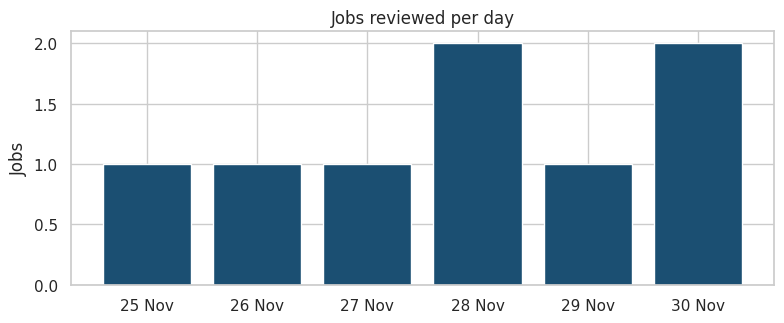

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(daily.index.strftime("%d %b"), daily["jobs_reviewed"], color="#1B4F72")
ax.set_title("Jobs reviewed per day")
ax.set_ylabel("Jobs")
fig.tight_layout()
fig.savefig(FIG / "jobs_per_day.png", dpi=150)
plt.show()


## Case 1 in SQL (SQLite)

In [5]:
con = sqlite3.connect(":memory:")
jobs.to_sql("job_data", con, index=False, if_exists="replace")

sql_daily = '''
SELECT ds,
       COUNT(*) AS jobs_reviewed,
       ROUND(COUNT(*) * 1.0 / 24, 4) AS jobs_per_hour,
       COUNT(*) * 1.0 / 86400 AS throughput
FROM job_data
GROUP BY ds
ORDER BY ds
'''
sql_out = pd.read_sql(sql_daily, con)
display(sql_out)
print("pandas jobs match SQL:",
      list(daily["jobs_reviewed"]) == list(sql_out["jobs_reviewed"]))


,ds,jobs_reviewed,jobs_per_hour,throughput
0,2020-11-25 00:00:00,1,0.0417,0.000012
1,2020-11-26 00:00:00,1,0.0417,0.000012
2,2020-11-27 00:00:00,1,0.0417,0.000012
3,2020-11-28 00:00:00,2,0.0833,0.000023
4,2020-11-29 00:00:00,1,0.0417,0.000012
5,2020-11-30 00:00:00,2,0.0833,0.000023


pandas jobs match SQL: True


## Case 2 — weekly engagement

Unique users with `event_type = engagement`. Weeks start Monday.
The week of 28 Apr is partial (log starts 1 May).


In [6]:
def week_start(s):
    return (s - pd.to_timedelta(s.dt.dayofweek, unit="D")).dt.normalize()

eng = events[events["event_type"] == "engagement"].copy()
eng["week"] = week_start(eng["occurred_at"])
users["created_week"] = week_start(users["created_at"])
users["activated_week"] = week_start(users["activated_at"])
emails["week"] = week_start(emails["occurred_at"])

weekly = (
    eng.groupby("week")
    .agg(engaged_users=("user_id", "nunique"), events=("user_id", "size"))
)
weekly["events_per_user"] = (weekly["events"] / weekly["engaged_users"]).round(1)
display(weekly)
print("peak", weekly["engaged_users"].idxmax().date(), int(weekly["engaged_users"].max()))
print("4 Aug", int(weekly.loc[pd.Timestamp("2014-08-04"), "engaged_users"]))


,engaged_users,events,events_per_user
week,,,
2014-04-28,701,8709,12.4
2014-05-05,1054,17532,16.6
2014-05-12,1094,17047,15.6
2014-05-19,1147,17890,15.6
2014-05-26,1113,17193,15.4
2014-06-02,1173,18608,15.9
2014-06-09,1219,18233,15.0
2014-06-16,1263,18976,15.0
2014-06-23,1249,18859,15.1


peak 2014-07-28 1443
4 Aug 1266


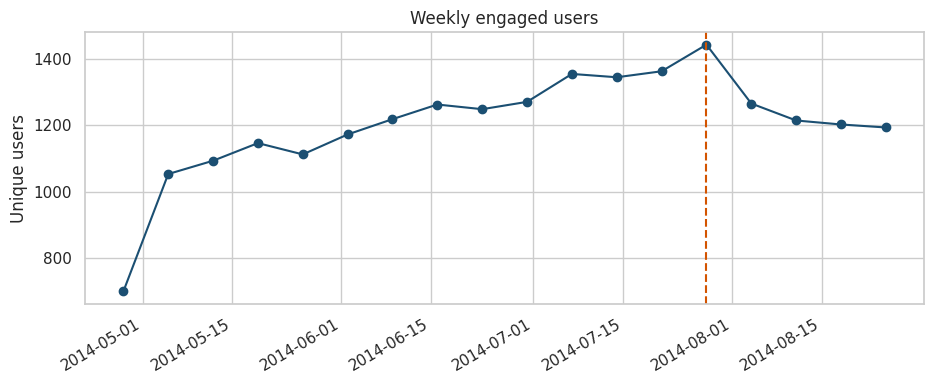

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 4))
ax.plot(weekly.index, weekly["engaged_users"], marker="o", color="#1B4F72")
ax.axvline(pd.Timestamp("2014-07-28"), color="#D35400", ls="--")
ax.set_title("Weekly engaged users")
ax.set_ylabel("Unique users")
fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(FIG / "weekly_engagement.png", dpi=150)
plt.show()


## User growth

In [8]:
created = users.groupby("created_week").size().rename("new_created")
activated = (
    users.dropna(subset=["activated_at"])
    .groupby("activated_week").size().rename("new_activated")
)
growth = pd.concat([created, activated], axis=1).fillna(0).astype(int)
growth["cum_created"] = growth["new_created"].cumsum()
growth["cum_activated"] = growth["new_activated"].cumsum()
display(growth.tail(12))
print("total created", len(users),
      "activated", int(users["activated_at"].notna().sum()),
      f"({users['activated_at'].notna().mean()*100:.1f}%)")


,new_created,new_activated,cum_created,cum_activated
2014-06-09,413,198,14191,6886
2014-06-16,421,222,14612,7108
2014-06-23,404,210,15016,7318
2014-06-30,405,199,15421,7517
2014-07-07,424,223,15845,7740
2014-07-14,426,215,16271,7955
2014-07-21,458,228,16729,8183
2014-07-28,476,234,17205,8417
2014-08-04,406,189,17611,8606
2014-08-11,473,250,18084,8856


total created 19066 activated 9381 (49.2%)


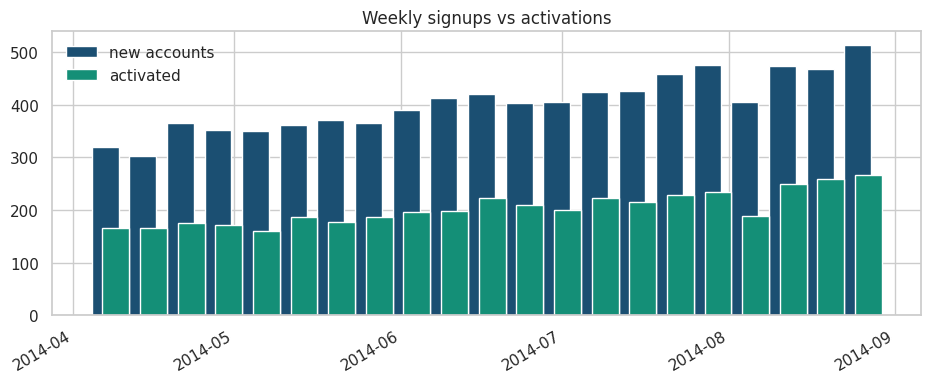

In [9]:
g = growth.loc["2014-04-01":]
fig, ax = plt.subplots(figsize=(9.5, 4))
ax.bar(g.index, g["new_created"], width=5, color="#1B4F72", label="new accounts")
ax.bar(g.index + pd.Timedelta(days=2), g["new_activated"], width=5, color="#148F77", label="activated")
ax.legend(frameon=False)
ax.set_title("Weekly signups vs activations")
fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(FIG / "user_growth.png", dpi=150)
plt.show()


## Weekly retention of the signup cohort

Denominator = users created in that week (pending included). Age 0 = signup week.
Only May–Aug 2014 cohorts, so they overlap the event window.


In [10]:
win = users[(users["created_at"] >= "2014-05-01") & (users["created_at"] < "2014-09-01")]
cohorts = win[["user_id", "created_week"]]
uw = eng[["user_id", "week"]].drop_duplicates().merge(cohorts, on="user_id")
uw["age"] = ((uw["week"] - uw["created_week"]).dt.days / 7).round().astype(int)
uw = uw[uw["age"] >= 0]
last = eng["week"].max()

rows = []
for age in range(0, 9):
    eligible = cohorts[cohorts["created_week"] + pd.Timedelta(weeks=age) <= last]
    n = eligible["user_id"].nunique()
    kept = uw[(uw["age"] == age) & (uw["user_id"].isin(eligible["user_id"]))]["user_id"].nunique()
    rows.append({"age": age, "eligible": n, "retained": kept, "pct": round(100 * kept / n, 1)})
ret = pd.DataFrame(rows)
display(ret)


,age,eligible,retained,pct
0,0,7298,3680,50.4
1,1,6784,2313,34.1
2,2,6316,1280,20.3
3,3,5843,832,14.2
4,4,5437,556,10.2
5,5,4961,386,7.8
6,6,4503,299,6.6
7,7,4077,261,6.4
8,8,3653,174,4.8


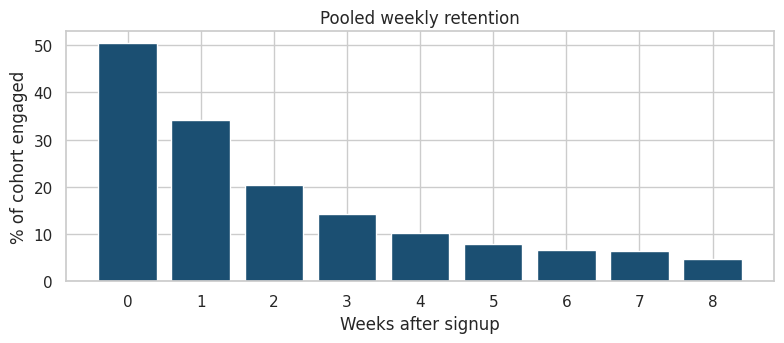

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(ret["age"].astype(str), ret["pct"], color="#1B4F72")
ax.set_xlabel("Weeks after signup")
ax.set_ylabel("% of cohort engaged")
ax.set_title("Pooled weekly retention")
fig.tight_layout()
fig.savefig(FIG / "retention_by_age.png", dpi=150)
plt.show()


## Weekly engagement per device family

In [12]:
PHONE = {
    "iphone 4s","iphone 5","iphone 5s","nexus 5","samsung galaxy s4",
    "samsung galaxy note","nokia lumia 635","htc one","amazon fire phone",
}
TABLET = {
    "ipad mini","ipad air","nexus 7","nexus 10","kindle fire",
    "windows surface","samsumg galaxy tablet",
}

def family(d):
    if d in PHONE: return "phone"
    if d in TABLET: return "tablet"
    return "computer"

eng["family"] = eng["device"].map(family)
wfam = eng.groupby(["week", "family"])["user_id"].nunique().unstack()[["computer", "phone", "tablet"]]
display(wfam.loc[["2014-07-28", "2014-08-04", "2014-08-25"]])


family,computer,phone,tablet
week,,,
2014-07-28,951,589,250
2014-08-04,913,491,173
2014-08-25,864,441,163


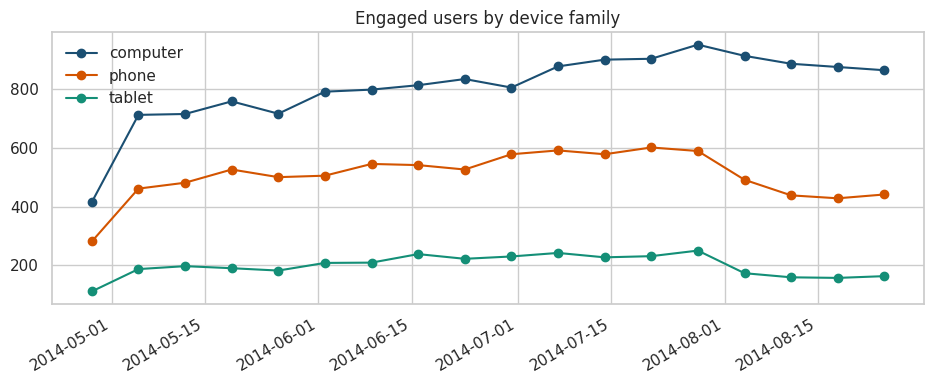

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 4))
for col, c in zip(wfam.columns, ["#1B4F72", "#D35400", "#148F77"]):
    ax.plot(wfam.index, wfam[col], marker="o", label=col, color=c)
ax.legend(frameon=False)
ax.set_title("Engaged users by device family")
fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(FIG / "device_weekly.png", dpi=150)
plt.show()


## Email engagement

Open rate = opens / (weekly digest + re-engagement sends).  
CTR = clickthroughs / sends.


In [14]:
wact = emails.groupby(["week", "action"]).size().unstack(fill_value=0)
sent = wact["sent_weekly_digest"] + wact["sent_reengagement_email"]
wact["open_rate"] = (100 * wact["email_open"] / sent).round(1)
wact["ctr"] = (100 * wact["email_clickthrough"] / sent).round(1)
display(wact[["sent_weekly_digest", "sent_reengagement_email", "email_open",
              "email_clickthrough", "open_rate", "ctr"]])
print("overall open", round(100 * (emails.action.eq("email_open").sum()) /
      emails.action.isin(["sent_weekly_digest", "sent_reengagement_email"]).sum(), 1))
print("overall ctr", round(100 * (emails.action.eq("email_clickthrough").sum()) /
      emails.action.isin(["sent_weekly_digest", "sent_reengagement_email"]).sum(), 1))


action,sent_weekly_digest,sent_reengagement_email,email_open,email_clickthrough,open_rate,ctr
week,,,,,,
2014-04-28,908,98,332,187,33.0,18.6
2014-05-05,2602,164,919,434,33.2,15.7
2014-05-12,2665,175,971,479,34.2,16.9
2014-05-19,2733,179,995,498,34.2,17.1
2014-05-26,2822,179,1026,453,34.2,15.1
2014-06-02,2911,199,993,492,31.9,15.8
2014-06-09,3003,190,1070,533,33.5,16.7
2014-06-16,3105,234,1161,563,34.8,16.9
2014-06-23,3207,187,1090,524,32.1,15.4


overall open 33.6
overall ctr 14.8


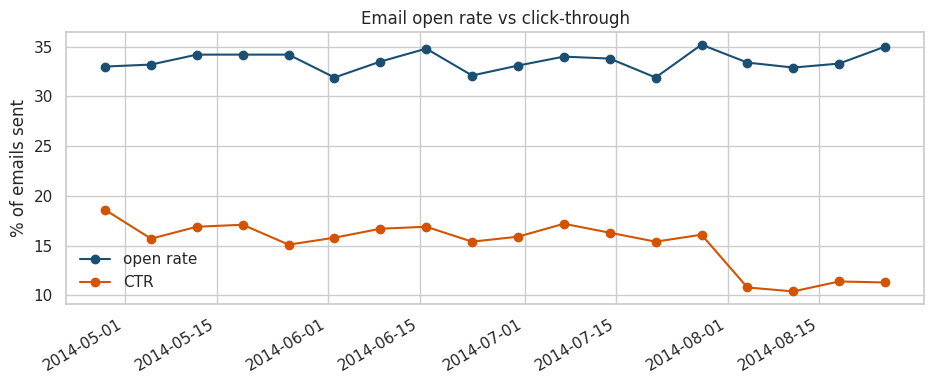

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 4))
ax.plot(wact.index, wact["open_rate"], marker="o", label="open rate", color="#1B4F72")
ax.plot(wact.index, wact["ctr"], marker="o", label="CTR", color="#D35400")
ax.legend(frameon=False)
ax.set_ylabel("% of emails sent")
ax.set_title("Email open rate vs click-through")
fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(FIG / "email_rates.png", dpi=150)
plt.show()


## Same weekly engagement in SQL

In [16]:
events.to_sql("events", con, index=False, if_exists="replace")
sql_eng = '''
SELECT DATE(occurred_at, '-' || ((CAST(strftime('%w', occurred_at) AS INT) + 6) % 7) || ' days') AS week,
       COUNT(DISTINCT user_id) AS engaged_users
FROM events
WHERE event_type = 'engagement'
GROUP BY 1
ORDER BY 1
'''
sql_w = pd.read_sql(sql_eng, con)
sql_w["week"] = pd.to_datetime(sql_w["week"])
merged = weekly[["engaged_users"]].reset_index().merge(sql_w, on="week", suffixes=("_pd", "_sql"))
print("pandas and SQL weekly users match:",
      (merged["engaged_users_pd"] == merged["engaged_users_sql"]).all())
display(merged.tail(5))
con.close()


pandas and SQL weekly users match: True


,week,engaged_users_pd,engaged_users_sql
13,2014-07-28,1443,1443
14,2014-08-04,1266,1266
15,2014-08-11,1215,1215
16,2014-08-18,1203,1203
17,2014-08-25,1194,1194


## Takeaways

- Case 1 is 8 rows. Per-hour and per-second numbers are the brief, not a KPI.
- Weekly engagement peaks at **1,443** (week of 28 Jul) then **1,266** the week of 4 Aug.
- Signups do not fall with it. Returning users do. Phone/tablet fall harder than computer.
- Email opens stay ~33–35%; CTR drops 16.1% → 10.8% the same week.
- That is a lead (mobile client, digest CTA), not a proof.
